In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
def wrangle(path, set_col_name):
    # Load data
    df = pd.read_csv(path, skiprows=1)

    # Convert first column to datetime 
    df['date'] = pd.to_datetime(df['unix'], unit = "s")
    df = df.sort_values(by='date', ascending=True)

    # Set index
    df.set_index('date', inplace=True)

    # Only keep certain columns 
    df = df[['open', 'high', 'low', 'close']]

    # # Rename columns
    # df = df.rename(columns={'close': set_col_name})

    return df

In [3]:
df = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitstamp_BTCUSD_1h.csv",
             'BTC')
# Ether = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitstamp_ETHUSD_1h.csv",
#                 'ETH')
# XRP = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitstamp_XRPUSD_1h.csv",
#               'XRP')


In [4]:
# df = pd.merge(Bitcoin, Ether, on='date', how='outer')
# df = pd.merge(df, XRP, on='date', how='outer')

In [5]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 58843 entries, 2018-05-15 06:00:00 to 2025-01-30 00:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    58843 non-null  float64
 1   high    58843 non-null  float64
 2   low     58843 non-null  float64
 3   close   58843 non-null  float64
dtypes: float64(4)
memory usage: 2.2 MB
None
                open           high            low          close
count   58843.000000   58843.000000   58843.000000   58843.000000
mean    29894.796271   30024.709189   29757.512305   29896.480240
std     23446.418898   23542.503930   23346.375882   23448.306107
min      3139.760000    3158.340000    3122.280000    3139.760000
25%      9200.935000    9229.940000    9169.080000    9201.075000
50%     24578.000000   24664.000000   24473.000000   24583.000000
75%     44316.040000   44559.865000   44119.000000   44316.915000
max    108293.000000  109356.000000  107655.000000  108276.000

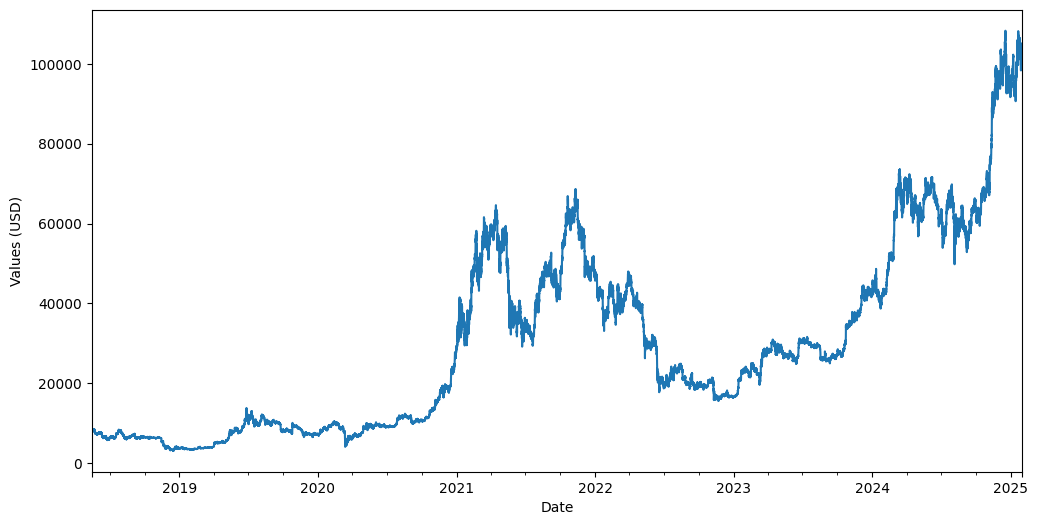

In [6]:
# Plot the 'close' prices
df['close'].plot(figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Values (USD)');

In [7]:
df

,open,high,low,close
date,,,,
2018-05-15 06:00:00,8733.86,8796.68,8707.28,8740.99
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90
...,...,...,...,...
2025-01-29 20:00:00,103583.00,104769.00,102866.00,104199.00
2025-01-29 21:00:00,104247.00,104389.00,103746.00,103746.00
2025-01-29 22:00:00,103747.00,104007.00,103415.00,103500.00


In [8]:
df.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv")